# Task 1 - Pipeline Orchestration and Data Sanitization
**Station:** Bhubaneswar (IGRA ID `INM00042971`)  
**Source:** NOAA Integrated Global Radiosonde Archive

This notebook covers Task 1, Levels 1–3: parsing the raw fixed-width IGRA file, cleaning it,
extracting the required stats/plot, refactoring into a reusable function, and finally
parallelizing + serializing to Parquet.

> Place `INM00042971-data.txt` in the same folder as this notebook before running.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "INM00042971-data.txt" 

## Level 1 - Foundational Ingestion

The IGRA file is fixed-width text, not a CSV. Each **header** line (starts with `#`) marks the
start of one balloon launch ("sounding"); the lines after it are the **data (level) records**
for that launch. Column positions come straight from `igra2-data-format.txt`.

In [2]:
def parse_igra(filepath):
    """
    Parses an IGRA data-file fixed-width file into two DataFrames:
    - df_headers: one row per sounding (launch) with metadata
    - df_levels : one row per altitude level, tagged with its sounding_id
    """
    headers, records = [], []
    current_id = -1

    with open(filepath, "r") as f:
        for line in f:
            if line.startswith("#"):
                current_id += 1
                headers.append(dict(
                    sounding_id=current_id,
                    station_id=line[1:12].strip(),
                    year=int(line[13:17]),
                    month=int(line[18:20]),
                    day=int(line[21:23]),
                    hour=int(line[24:26]),
                    numlev=int(line[32:36]),
                    lat=int(line[55:62]) / 10000.0,
                    lon=int(line[63:71]) / 10000.0,
                ))
            else:
                records.append(dict(
                    sounding_id=current_id,
                    press=int(line[9:15]),   # Pa*... (see below, /100 -> hPa)
                    gph=int(line[16:21]),    # meters
                    temp=int(line[22:27]),   # tenths of degC
                    rh=int(line[28:33]),     # tenths of percent
                ))

    return pd.DataFrame(headers), pd.DataFrame(records)


df_headers, df_levels = parse_igra(DATA_PATH)
print(f"Soundings (launches): {len(df_headers):,}")
print(f"Total level records : {len(df_levels):,}")
df_headers.head()

Soundings (launches): 51,619
Total level records : 1,560,325


,sounding_id,station_id,year,month,day,hour,numlev,lat,lon
0,0,INM00042971,1971,7,25,1,15,20.25,85.8333
1,1,INM00042971,1971,7,25,12,8,20.25,85.8333
2,2,INM00042971,1971,7,29,0,9,20.25,85.8333
3,3,INM00042971,1971,7,31,0,3,20.25,85.8333
4,4,INM00042971,1971,8,1,12,12,20.25,85.8333


**Cleaning:** `-9999` and `-8888` are IGRA's missing-value(see format spec); they must
become `NaN`. We also convert raw units to physical units:
pressure Pa→hPa (÷100), temperature/RH tenths→whole units (÷10).

In [3]:
def clean_levels(df_levels):
    df = df_levels.copy()
    cols = ["press", "gph", "temp", "rh"]
    df[cols] = df[cols].replace([-9999, -8888], np.nan)   # exclusion strategy for missing codes
    df["press_hpa"] = df["press"] / 100
    df["temp_c"] = df["temp"] / 10
    df["rh_pct"] = df["rh"] / 10
    return df


df_clean = clean_levels(df_levels)
missing_pct = df_clean[["press", "gph", "temp", "rh"]].isna().mean() * 100
print("Missing value % per column:")
print(missing_pct.round(2))

Missing value % per column:
press    16.71
gph      52.38
temp     47.96
rh       99.87
dtype: float64


The file holds 50k+ launches spanning 1971–2026, so
"maximum altitude" etc. only make physical sense for a *single* flight, not the whole archive.
We pick a recent, densely-recorded sounding as our representative flight.

In [4]:
merged = df_clean.merge(df_headers, on="sounding_id")

# pick the most data-dense sounding from the last few years as our representative flight
recent = merged[merged["year"] >= 2023]
density = recent.dropna(subset=["gph", "temp_c"]).groupby("sounding_id").size().sort_values(ascending=False)
demo_id = density.index[0]

flight = merged[merged["sounding_id"] == demo_id].dropna(subset=["gph", "temp_c"]).sort_values("gph")
info = df_headers[df_headers.sounding_id == demo_id].iloc[0]
print(f"Representative flight: {int(info.year)}-{int(info.month):02d}-{int(info.day):02d} "
      f"{int(info.hour):02d}:00 UTC, {len(flight)} valid levels")
flight.head()

Representative flight: 2024-09-27 00:00 UTC, 116 valid levels


,sounding_id,press,gph,temp,rh,press_hpa,temp_c,rh_pct,station_id,year,month,day,hour,numlev,lat,lon
1290060,50107,100200.0,45.0,260.0,NaN,1002.0,26.0,NaN,INM00042971,2024,9,27,0,116,20.25,85.8333
1290061,50107,100000.0,63.0,262.0,NaN,1000.0,26.2,NaN,INM00042971,2024,9,27,0,116,20.25,85.8333
1290062,50107,99970.0,65.0,263.0,NaN,999.7,26.3,NaN,INM00042971,2024,9,27,0,116,20.25,85.8333
1290063,50107,98140.0,229.0,271.0,NaN,981.4,27.1,NaN,INM00042971,2024,9,27,0,116,20.25,85.8333
1290064,50107,97440.0,294.0,267.0,NaN,974.4,26.7,NaN,INM00042971,2024,9,27,0,116,20.25,85.8333


### Required Level 1 outputs: max altitude, temperature variance, ground-apogee pressure delta

In [5]:
max_altitude_m = flight["gph"].max()
temp_variance = flight["temp_c"].var()

ground_pressure = flight.sort_values("gph").iloc[0]["press_hpa"]
apogee_pressure = flight.loc[flight["gph"].idxmax(), "press_hpa"]
pressure_delta = ground_pressure - apogee_pressure

print(f"Max altitude               : {max_altitude_m:,.0f} m")
print(f"Temperature variance       : {temp_variance:.2f} degC^2")
print(f"Ground pressure            : {ground_pressure:.1f} hPa")
print(f"Apogee pressure            : {apogee_pressure:.1f} hPa")
print(f"Pressure delta (ground-apogee): {pressure_delta:.1f} hPa")

Max altitude               : 35,328 m
Temperature variance       : 1030.86 degC^2
Ground pressure            : 1002.0 hPa
Apogee pressure            : 5.4 hPa
Pressure delta (ground-apogee): 996.6 hPa


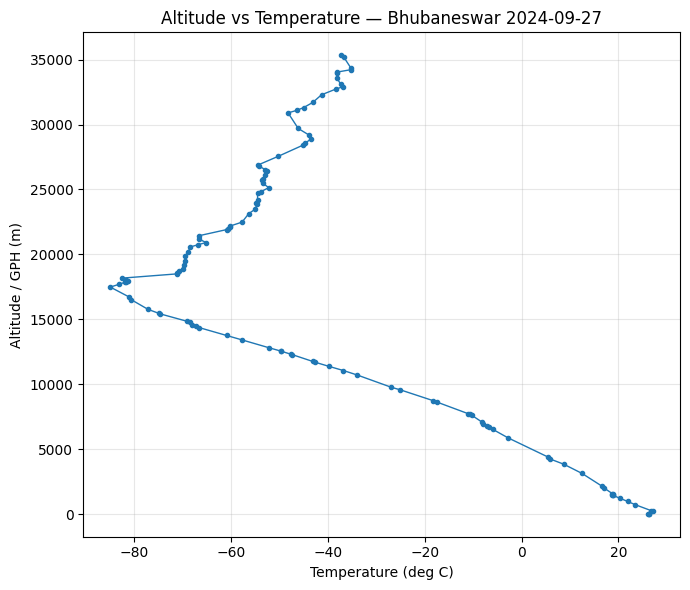

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(flight["temp_c"], flight["gph"], marker="o", markersize=3, linewidth=1)
ax.set_xlabel("Temperature (deg C)")
ax.set_ylabel("Altitude / GPH (m)")
ax.set_title(f"Altitude vs Temperature — Bhubaneswar {int(info.year)}-{int(info.month):02d}-{int(info.day):02d}")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("altitude_vs_temperature.png", dpi=150)
plt.show()

## Level 2- Functional Modularization

Wrap the whole ingest-clean pipeline into one reusable function that takes any raw IGRA file
path and returns a single sanitized, analysis-ready DataFrame (levels + header metadata merged).

In [7]:
def clean_telemetry(filepath):
    """
    given a raw IGRA data-file .txt file,
    returns one clean, merged DataFrame (level records + sounding metadata),
    with missing codes converted to NaN and units converted to physical units.
    """
    df_headers, df_levels = parse_igra(filepath)
    df_levels_clean = clean_levels(df_levels)
    return df_levels_clean.merge(df_headers, on="sounding_id")


sanitized_df = clean_telemetry(DATA_PATH)
print(sanitized_df.shape)
sanitized_df.head()

(1560325, 16)


,sounding_id,press,gph,temp,rh,press_hpa,temp_c,rh_pct,station_id,year,month,day,hour,numlev,lat,lon
0,0,99300.0,NaN,262.0,937.0,993.0,26.2,93.7,INM00042971,1971,7,25,1,15,20.25,85.8333
1,0,95000.0,NaN,250.0,824.0,950.0,25.0,82.4,INM00042971,1971,7,25,1,15,20.25,85.8333
2,0,85000.0,1408.0,192.0,871.0,850.0,19.2,87.1,INM00042971,1971,7,25,1,15,20.25,85.8333
3,0,70000.0,3057.0,110.0,961.0,700.0,11.0,96.1,INM00042971,1971,7,25,1,15,20.25,85.8333
4,0,69200.0,NaN,104.0,NaN,692.0,10.4,NaN,INM00042971,1971,7,25,1,15,20.25,85.8333


## Level 3- Parallelization

To scale beyond one file, we split the record into year-range chunks and parse+clean each chunk in a **separate process**
using `ProcessPoolExecutor`. The worker function lives in `parallel_utils.py` (a real module,
not a notebook cell) because `ProcessPoolExecutor` has to pickle the function it sends to each
worker. Results are concatenated and serialized to **Parquet** for fast reloading.

In [8]:
import time
from concurrent.futures import ProcessPoolExecutor
from parallel_utils import parse_and_clean_year_range

year_chunks = [(1971, 1990), (1991, 2005), (2006, 2015), (2016, 2026)]
args = [(DATA_PATH, start, end) for start, end in year_chunks]

t0 = time.time()
with ProcessPoolExecutor(max_workers=4) as executor:
    results = list(executor.map(parse_and_clean_year_range, args))

full_df = pd.concat(results, ignore_index=True)
elapsed = time.time() - t0
print(f"Parallel-parsed {len(full_df):,} rows across {len(year_chunks)} chunks in {elapsed:.2f}s")

full_df.to_parquet("bhubaneswar_cleaned.parquet", index=False)
print("Saved bhubaneswar_cleaned.parquet")

Parallel-parsed 1,560,325 rows across 4 chunks in 2.00s
Saved bhubaneswar_cleaned.parquet


**Sanity check:** row count from the parallel path should match the single-threaded path above.

In [9]:
assert len(full_df) == len(sanitized_df), "Row count mismatch between serial and parallel pipelines!"
print("Row counts match:", len(full_df), "==", len(sanitized_df))

Row counts match: 1560325 == 1560325
